## 5. QA checks — review this output before trusting the export

**Grain definition (QA round 1):** month × county × **Plan Type** × plan × category — the same plan name can carry two lines of business in one county.

**Transition dedup (QA round 1):** Nov–Dec 2022 duals rows reported under both old and new names with identical counts; exact duplicates dropped.

**SCAN aggregation (QA round 2):** before 2019 SCAN's regular and nursing home certified lines had separate names; from Jan 2019 both share `SCAN Health Plan/<county>`, leaving two indistinguishable rows per month. Decision: treat SCAN as ONE plan across all eras (map both old names to SCAN Health Plan, sum at the grain). `Plan Name Raw` keeps the audit trail.

**Check A:** duplicate grain rows after dedup + aggregation — expect 0.

**Check B:** L.A. Care continuity in LA County — unbroken series, no 2022 gap or spike.

**Check C:** statewide yearly totals — smooth apart from real events (ACA 2014, Cal MediConnect end 2022, redeterminations 2024+). Compare against the previous run: totals should be unchanged since aggregation only reshapes rows.

## 1. Load the raw extract

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIR = Path('..') / 'data'
log = json.loads((DATA_DIR / 'extraction_log.json').read_text())
raw_path = DATA_DIR / 'raw' / log['raw_file']

df = pd.read_csv(raw_path)
print('Loaded', raw_path.name, df.shape)

Loaded medi_cal_mc_enrollment_raw_2026-07-05.csv (31178, 8)


## 2. Column names and types

In [2]:
# Strip column name whitespace, drop the empty trailing column
df.columns = [c.strip() for c in df.columns]
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])

# Enrollee counts: ' 293,311 ' -> 293311.0 (suppressed cells -> NaN)
df['Enrollees'] = pd.to_numeric(
    df['Count of Enrollees'].astype(str).str.strip().str.replace(',', '', regex=False),
    errors='coerce')
df['Suppressed'] = df['Count of Enrollees Annotation Code'].notna()

# '2007-01' -> datetime (first of month)
df['Month'] = pd.to_datetime(df['Enrollment Month'], format='%Y-%m')

print(df[['Month', 'Enrollees', 'Suppressed']].describe(include='all'))
print()
print('Suppressed rows:', int(df['Suppressed'].sum()))

                                Month     Enrollees Suppressed
count                           31178  3.048900e+04      31178
unique                            NaN           NaN          2
top                               NaN           NaN      False
freq                              NaN           NaN      30489
mean    2018-05-11 08:11:28.177561088  7.410067e+04        NaN
min               2007-01-01 00:00:00  1.100000e+01        NaN
25%               2014-08-01 00:00:00  1.461000e+03        NaN
50%               2018-12-01 00:00:00  1.431100e+04        NaN
75%               2022-11-23 12:00:00  6.977600e+04        NaN
max               2026-06-01 00:00:00  2.754051e+06        NaN
std                               NaN  1.989979e+05        NaN

Suppressed rows: 689


## 3. Plan name harmonization

Two layers:
1. **Mechanical:** strip whitespace and remove the `/County` style suffix (`'Health Net / LA'` → `'Health Net'`) to get `Plan Base`.
2. **Explicit mapping:** harmonize era variants of the same plan (abbreviated pre 2022 names vs full post 2022 names). We only map plans we have verified; everything else keeps its mechanical base name.

`Plan Name` (raw) is kept forever so any mapping decision is reversible and auditable in the blog post.

In [3]:
# Layer 1: mechanical base name (strip '/<place>' suffix and whitespace)
df['Plan Base'] = (df['Plan Name'].astype(str)
                   .str.strip()
                   .str.replace(r'\s*/\s*[^/]*$', '', regex=True)
                   .str.strip())

print('Raw plan names:', df['Plan Name'].nunique())
print('After suffix strip:', df['Plan Base'].nunique())

Raw plan names: 477
After suffix strip: 198


In [4]:
# Layer 2: explicit harmonization for verified era variants (extend as we verify more)
# Verified via month counts in nb00: e.g. LA CARE (188 months) + L.A. Care Health Plan/Los Angeles (46) = 234 = full range, no overlap
HARMONIZE = {
    'LA CARE': 'L.A. Care Health Plan',
    'LA CARE CCI': 'L.A. Care Health Plan',                    # CCI program line, categorized separately below
    'L.A. Care Health Plan (CMC)': 'L.A. Care Health Plan',
    'Health Net': 'Health Net Community Solutions',
    'Health Net Comm Solutions LA': 'Health Net Community Solutions',
    'Health Net Los Angeles CCI': 'Health Net Community Solutions',
    'Health Net Community Solutions (CMC)': 'Health Net Community Solutions',
    'Hlth Plan of San Mateo': 'Health Plan of San Mateo',
    'AltaMed Hlth Sr. Buena Care': 'AltaMed Health Sr. Buena Care',
    'Alta Med Health Senior Buenacare': 'AltaMed Health Sr. Buena Care',
    'AIDS HlthCare Found': 'AIDS Healthcare Foundation',
    'SCAN Hlth Plan': 'SCAN Health Plan',
    'SCAN (Nurs hm cert)': 'SCAN Health Plan',   # post 2019 the file merges both SCAN lines under one name, so we merge all eras
    'Partnership HealthPlan of CA': 'Partnership HealthPlan of California',
}
df['Plan Clean'] = df['Plan Base'].replace(HARMONIZE)
print('After harmonization:', df['Plan Clean'].nunique())

After harmonization: 184


## 4. Plan category

Coarse grouping for dashboard filters. The blog's main story uses Medical; Dental, PACE, and the duals demonstrations (CMC/CCI) stay available as filter values.

In [5]:
def categorize(row):
    pt = str(row['Plan Type']).upper()
    name = str(row['Plan Name']).upper()
    if 'DENTAL' in pt or 'DENTAL' in name:
        return 'Dental'
    if 'PACE' in pt or 'PACE' in name:
        return 'PACE'
    if 'CCI' in name or 'CMC' in name or 'MEDICONNECT' in name.replace(' ', ''):
        return 'Duals (CMC/CCI)'
    return 'Medical'

df['Plan Category'] = df.apply(categorize, axis=1)
print(df['Plan Category'].value_counts())
print()
print(pd.crosstab(df['Plan Type'], df['Plan Category']))

Plan Category
Medical            23132
PACE                4010
Dental              2275
Duals (CMC/CCI)     1761
Name: count, dtype: int64

Plan Category                    Dental  Duals (CMC/CCI)  Medical  PACE
Plan Type                                                              
CCS Demonstration                     0                0       68     0
COHS                                  0                0     3298     0
Cal MediConnect                       0             1761       10     0
Commercial Plan (2 Plan)              0                0     1780     0
County Organized Health Systems       0                0     1746     0
Dental                             2275                0        0     0
Geographic Managed Care               0                0     2356     0
Imperial Model                        0                0      244     0
Local Initiative (2 Plan)             0                0     1270     0
PACE                                  0                0        0  

## 5. QA checks — review this output before trusting the export

**Check A:** after harmonization, the same plan + county + month + category should not appear twice. Duplicates mean the mapping merged two things that coexisted (like the SCAN nursing home line) and needs a fix.

**Check B:** era continuity for L.A. Care in LA County: one unbroken monthly series, no gap and no double counting around the 2022 name change.

**Check C:** statewide total by year should move smoothly (big jumps flag double counting; the known real events are ACA expansion 2014 and the 2023 COHS expansion).

In [6]:
GRAIN = ['Month', 'County', 'Plan Type', 'Plan Clean', 'Plan Category']

# Step 1 — transition dedup: same grain AND same enrollee count = double reporting during the 2022 renaming
before = len(df)
df = df.drop_duplicates(subset=GRAIN + ['Enrollees'], keep='first').copy()
print('Transition duplicate rows dropped:', before - len(df))

# Step 2 — aggregate to the grain: sums plans whose product lines share one name (SCAN post 2019)
# min_count=1 keeps fully suppressed groups as NaN instead of 0
before = len(df)
df = (df.groupby(GRAIN, as_index=False)
        .agg(**{
            'Enrollees': ('Enrollees', lambda s: s.sum(min_count=1)),
            'Suppressed': ('Suppressed', 'any'),
            'Plan Name Raw': ('Plan Name', lambda s: ' + '.join(sorted(s.astype(str).unique()))),
        }))
print('Rows merged by aggregation:', before - len(df))

# Check A: any grain duplicates left? (expect 0)
dupes = df[df.duplicated(GRAIN, keep=False)]
print('Remaining duplicate grain rows (expect 0):', len(dupes))
if len(dupes):
    print(dupes.sort_values(['Plan Clean', 'Month']).head(20))

Transition duplicate rows dropped: 4
Rows merged by aggregation: 743
Remaining duplicate grain rows (expect 0): 0


L.A. Care Medical rows: 234 | span: 2007-01 to 2026-06
Missing months: []
Months with >1 row: 0


<Axes: title={'center': 'L.A. Care Health Plan — LA County enrollment'}, xlabel='Month'>

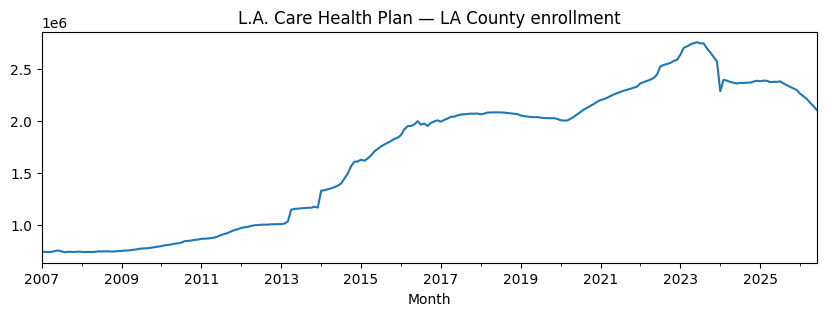

In [7]:
# Check B: L.A. Care continuity in LA County (Medical only)
lacare = df[(df['Plan Clean'] == 'L.A. Care Health Plan')
            & (df['County'].str.contains('Los Angeles', case=False, na=False))
            & (df['Plan Category'] == 'Medical')].sort_values('Month')
months = lacare['Month'].dt.to_period('M')
expected = pd.period_range(months.min(), months.max(), freq='M')
missing = expected.difference(months)
print('L.A. Care Medical rows:', len(lacare), '| span:', months.min(), 'to', months.max())
print('Missing months:', list(missing))
print('Months with >1 row:', int((months.value_counts() > 1).sum()))
lacare.set_index('Month')['Enrollees'].plot(title='L.A. Care Health Plan — LA County enrollment', figsize=(10, 3))

In [8]:
# Check C: statewide total by year (all categories vs Medical only)
yearly = df.groupby([df['Month'].dt.year, 'Plan Category'])['Enrollees'].sum().unstack(fill_value=0)
yearly['Total'] = yearly.sum(axis=1)
print((yearly / 1e6).round(1))

Plan Category  Dental  Duals (CMC/CCI)  Medical  PACE  Total
Month                                                       
2007              4.6              0.0     39.1   0.0   43.8
2008              4.9              0.0     40.7   0.0   45.7
2009              5.4              0.0     43.8   0.0   49.2
2010              5.9              0.0     48.2   0.0   54.1
2011              6.1              0.0     53.2   0.0   59.4
2012              6.1              0.0     58.2   0.0   64.3
2013              7.5              0.0     67.8   0.0   75.3
2014              9.0              0.3     93.3   0.0  102.6
2015             10.8              1.4    115.9   0.0  128.1
2016             11.4              1.4    126.5   0.0  139.3
2017             10.9              1.4    129.4   0.0  141.7
2018             10.2              1.3    128.1   0.0  139.6
2019              9.6              1.3    124.9   0.1  135.9
2020              9.7              1.3    127.3   0.1  138.4
2021             10.6   

## 6. Export the Tableau ready CSV

Tidy grain: one row per month × county × plan × category. Raw plan name kept for audit.

In [9]:
out_cols = ['Month', 'County', 'Plan Type', 'Plan Category', 'Plan Clean', 'Plan Name Raw', 'Enrollees', 'Suppressed']
clean = df[out_cols].rename(columns={'Plan Clean': 'Plan'})

out_path = DATA_DIR / 'medi_cal_enrollment_clean.csv'
clean.to_csv(out_path, index=False)
print('Wrote', out_path, clean.shape)
clean.head()

Wrote ../data/medi_cal_enrollment_clean.csv (30431, 8)


,Month,County,Plan Type,Plan Category,Plan,Plan Name Raw,Enrollees,Suppressed
0,2007-01-01,Alameda,PACE,PACE,OnLok Senior Hlth dba OnLok Lifeways,OnLok Senior Hlth dba OnLok Lifeways/Alameda,85.0,False
1,2007-01-01,Alameda,Special Project,Medical,Cntr Elders Indep,Cntr Elders Indep/Alameda,372.0,False
2,2007-01-01,Alameda,Two-Plan,Medical,Alameda Alliance for Hlth,Alameda Alliance for Hlth,73072.0,False
3,2007-01-01,Alameda,Two-Plan,Medical,Anthem Blue Cross Partnership Plan,Anthem Blue Cross Partnership Plan/Alameda,27670.0,False
4,2007-01-01,Contra Costa,Special Project,Medical,Center for Elders Independence,Center for Elders Independence,26.0,False


---

**Next:** connect Tableau Public Desktop to `medi_cal_enrollment_clean.csv` (Phase 1 of the build), and stand up the DuckDB + pandas parity notebooks against the same file.